In [1]:
# libraries for this lab
import json
import math
import random
import time
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# last 4 of my SJSUid - 0670
SID4 = 670
SEED = SID4

# set seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# device: cuda in GPU lab, mps on my mac, else cpu
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("SID4: %04d" % SID4)
print("SEED:", SEED)
print("device:", device)


SID4: 0670
SEED: 670
device: mps


# Sneha Singh
## DATA 266 — Lab 1, Part 1
GPT-style LLM from scratch on TinyStories (character level)


## Part 1. GPT from scratch

I build a small GPT on TinyStories. Tokenization is character level, not BPE. I write attention myself. No `nn.Transformer` and no `nn.MultiheadAttention`.

- **1.1** data (this part first)
- **1.2** model
- **1.3** train + generate
- **1.4** three failure cases

`SMOKE=true` in `config.json` means a tiny run on my laptop. Full 100K / 10K and 10 epochs are the same code with `smoke` set to false, run on GPU.


## 1.1 Data preprocessing

Lab asks for four things: load TinyStories, character tokenize, fixed-length input/target windows, and my own 100K train / 10K val split.


### 1.1.0 Paths and config

I keep numbers in `config.json` so there are no hard-coded personal paths. Prints use repo-relative paths only (`task1_llm/...`), never `/Users/...`. Same notebook should run on my laptop and in the GPU lab.


In [2]:
# folders: notebook may be opened from src/ or from Lab-1 root
cwd = Path.cwd()
if (cwd / "config.json").exists():
    SRC = cwd
elif (cwd / "task1_llm" / "sneha_singh" / "src" / "config.json").exists():
    SRC = cwd / "task1_llm" / "sneha_singh" / "src"
else:
    SRC = cwd

MEMBER = SRC.parent
TASK = MEMBER.parent
DATA_RAW = TASK / "data"
DATA_PROC = MEMBER / "data_processed"
CKPT = MEMBER / "checkpoints"
OUT = MEMBER / "outputs"

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROC.mkdir(parents=True, exist_ok=True)
CKPT.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# repo root = Lab-1. print only relative paths (lab: no personal file paths)
REPO = TASK.parent

def relpath(p):
    p = Path(p).resolve()
    try:
        return str(p.relative_to(REPO.resolve()))
    except ValueError:
        return p.name

# load my run settings
with open(SRC / "config.json") as f:
    CFG = json.load(f)

SMOKE = bool(CFG["smoke"])
BLOCK_SIZE = int(CFG["block_size"])
N_TRAIN = int(CFG["n_train_smoke"] if SMOKE else CFG["n_train_full"])
N_VAL = int(CFG["n_val_smoke"] if SMOKE else CFG["n_val_full"])

print("SRC:", relpath(SRC))
print("DATA_RAW:", relpath(DATA_RAW))
print("DATA_PROC:", relpath(DATA_PROC))
print("SMOKE:", SMOKE)
print("BLOCK_SIZE:", BLOCK_SIZE)
print("N_TRAIN:", N_TRAIN)
print("N_VAL:", N_VAL)
print("n_layer / n_head / n_embd:", CFG["n_layer"], CFG["n_head"], CFG["n_embd"])


SRC: task1_llm/sneha_singh/src
DATA_RAW: task1_llm/data
DATA_PROC: task1_llm/sneha_singh/data_processed
SMOKE: True
BLOCK_SIZE: 128
N_TRAIN: 256
N_VAL: 64
n_layer / n_head / n_embd: 4 4 256


### 1.1.1 Load TinyStories

I use the official TinyStories valid `.txt` from Hugging Face. Stories are split on `<|endoftext|>`. Raw file stays in shared `task1_llm/data/` and is not pushed to GitHub.


In [3]:
# download TinyStories valid text if I do not have it yet
raw_path = DATA_RAW / CFG["dataset_file"]
if not raw_path.exists():
    print("downloading TinyStories-valid.txt from Hugging Face")
    urlretrieve(CFG["dataset_url"], raw_path)
    print("saved", relpath(raw_path))
else:
    print("already have", relpath(raw_path))

# read the file
raw = raw_path.read_text(encoding="utf-8", errors="ignore")
print("file chars:", len(raw))

# split stories
if "<|endoftext|>" in raw:
    stories = [s.strip() for s in raw.split("<|endoftext|>") if s.strip()]
else:
    stories = [s.strip() for s in raw.split("\n\n") if s.strip()]

print("n stories:", len(stories))
print("--- first story (cut) ---")
print(stories[0][:400])


already have task1_llm/data/TinyStories-valid.txt
file chars: 19432979
n stories: 21990
--- first story (cut) ---
Spot. Spot saw the shiny car and said, "Wow, Kitty, your car is so bright and clean!" Kitty smiled and replied, "Thank you, Spot. I polish it every day."
After playing with the car, Kitty and Spot felt thirsty. They found a small pond with clear water. They drank the water and felt very happy. They played together all day and became best friends.


### 1.1.2 Character tokenizer

Lab wants my own `char_to_idx` and `idx_to_char`. I build them from the text I actually use. No tiktoken, no Hugging Face tokenizer.


In [4]:
# smoke uses fewer stories so the laptop stays light
if SMOKE:
    use_stories = stories[:80]
else:
    use_stories = stories

# one long string for character language modelling
text = "\n\n".join(use_stories)
print("text chars:", len(text))

# vocab = sorted unique characters
chars = sorted(set(text))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

print("vocab_size:", vocab_size)
print("first 40 chars in vocab:", "".join(chars[:40]))

# encode / decode helpers
def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return "".join(idx_to_char[i] for i in ids)

# check round trip on a short piece
sample = text[:80]
print("round trip ok:", decode(encode(sample)) == sample)
print("sample:", repr(sample))


text chars: 55406
vocab_size: 57
first 40 chars in vocab: 
 !"',-.?ABCDEFGHIJKLMNOPRSTVWYabcdefghi
round trip ok: True
sample: 'Spot. Spot saw the shiny car and said, "Wow, Kitty, your car is so bright and cl'


### 1.1.3 Fixed-length input–target sequences

Autoregressive LM: the model sees `block_size` characters and predicts the next one at every position. So `x` is chars `[0 .. T-1]` and `y` is chars `[1 .. T]`.

Windows are **non-overlapping** (`stride = block_size`). I build every valid start across the whole corpus, then randomly pick `need` of them with my seed — not just the first chunk of the file.


In [5]:
# integer ids for the whole text
data_ids = np.array(encode(text), dtype=np.int64)
print("n tokens (chars):", len(data_ids))

# need block_size+1 chars per window (x plus the next char)
win = BLOCK_SIZE + 1
# non-overlapping windows across the FULL corpus, then random sample `need`
stride = int(CFG.get("window_stride", BLOCK_SIZE))
stride = max(1, stride)
starts_all = np.arange(0, len(data_ids) - win + 1, stride)
print("window stride:", stride, "(non-overlap)" if stride >= BLOCK_SIZE else "(overlapping)")
print("max windows in file:", len(starts_all))

need = N_TRAIN + N_VAL
if len(starts_all) < need:
    raise ValueError(
        "not enough text for %d windows of size %d with stride %d. got %d. "
        "use TinyStories-train / more stories, or keep smoke=true."
        % (need, BLOCK_SIZE, stride, len(starts_all))
    )

# random sample from whole file (seed=SEED), not only the front of the corpus
rng_win = np.random.default_rng(SEED)
pick = rng_win.choice(len(starts_all), size=need, replace=False)
starts = np.sort(starts_all[pick])
windows = np.stack([data_ids[i : i + win] for i in starts])
X_all = windows[:, :-1]
Y_all = windows[:, 1:]

print("sampled windows:", need, "from", len(starts_all))
print("X_all", X_all.shape, "Y_all", Y_all.shape)
print("start char range: %d .. %d" % (int(starts.min()), int(starts.max())))
print("one x decode:\n", decode(X_all[0].tolist())[:200])
print("one y decode (shifted):\n", decode(Y_all[0].tolist())[:200])


n tokens (chars): 55406
window stride: 128 (non-overlap)
max windows in file: 432
sampled windows: 320 from 432
X_all (320, 128) Y_all (320, 128)
start char range: 0 .. 55040
one x decode:
 Spot. Spot saw the shiny car and said, "Wow, Kitty, your car is so bright and clean!" Kitty smiled and replied, "Thank you, Spot
one y decode (shifted):
 pot. Spot saw the shiny car and said, "Wow, Kitty, your car is so bright and clean!" Kitty smiled and replied, "Thank you, Spot.


### 1.1.4 My train / val split

Each member makes their own split. I shuffle with seed 670, then take train and val. Processed files go under my folder (`data_processed/`), not the shared raw `data/` folder.


In [6]:
# shuffle with my seed for my own train/val split
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(X_all))
X_all = X_all[perm]
Y_all = Y_all[perm]

X_train, Y_train = X_all[:N_TRAIN], Y_all[:N_TRAIN]
X_val, Y_val = X_all[N_TRAIN : N_TRAIN + N_VAL], Y_all[N_TRAIN : N_TRAIN + N_VAL]

print("train", X_train.shape, Y_train.shape)
print("val  ", X_val.shape, Y_val.shape)

# save tokenizer + arrays under my processed folder
tok_path = DATA_PROC / "char_tokenizer.json"
with open(tok_path, "w") as f:
    json.dump(
        {
            "char_to_idx": char_to_idx,
            "idx_to_char": {str(k): v for k, v in idx_to_char.items()},
            "vocab_size": vocab_size,
            "block_size": BLOCK_SIZE,
            "smoke": SMOKE,
            "n_train": N_TRAIN,
            "n_val": N_VAL,
            "seed": SEED,
        },
        f,
        indent=2,
    )

np.savez_compressed(
    DATA_PROC / "sequences.npz",
    X_train=X_train,
    Y_train=Y_train,
    X_val=X_val,
    Y_val=Y_val,
)

print("saved", relpath(tok_path))
print("saved", relpath(DATA_PROC / "sequences.npz"))
print("1.1 data preprocessing done")


train (256, 128) (256, 128)
val   (64, 128) (64, 128)
saved task1_llm/sneha_singh/data_processed/char_tokenizer.json
saved task1_llm/sneha_singh/data_processed/sequences.npz
1.1 data preprocessing done


## 1.2 GPT model implementation

I write a decoder-only GPT. Each block has multi-head self-attention, layer norm, a feed-forward net, and residuals. Attention uses a causal mask so a character cannot look at the future. I do not use `nn.Transformer` or `nn.MultiheadAttention`.


### 1.2.1 Token and positional embeddings

Each character id becomes a learned vector. I also add a learned vector for the position (0, 1, 2, ...). The model can then tell *what* character it is and *where* it is in the window.


### 1.2.2 Causal multi-head self-attention

I make Q, K, V with a linear layer, split into heads, then do `QK^T / sqrt(d)`. Before softmax I hide the future with an upper-triangle mask. That is the causal part.


In [7]:
# causal multi-head self-attention from scratch
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        # one linear for q, k, v together
        self.c_attn = nn.Linear(n_embd, 3 * n_embd)
        self.c_proj = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        # True = block this position (the future)
        mask = torch.triu(torch.ones(block_size, block_size), diagonal=1).bool()
        self.register_buffer("causal_mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=2)
        # (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        # attention scores
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.causal_mask[:T, :T], float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_drop(self.c_proj(y))
        return y


### 1.2.3 Transformer block

One block is: layer norm, causal attention, residual, then layer norm, feed-forward, residual. I stack `n_layer` of these.


In [8]:
# one GPT block: LN + attention + residual, then LN + FFN + residual
class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


### 1.2.4 Language modelling head

After the last block I project hidden size back to vocab size. Each position gives a score for the next character.

I tie `lm_head.weight` to `tok_emb.weight` (standard GPT). I also use GPT-2 style init: Normal(0, 0.02), with residual projections scaled by `1/sqrt(2*n_layer)`.


In [9]:
# full GPT: embeddings -> N blocks -> LN -> LM head
# weight tying + GPT-2 style init (std=0.02, residual proj scaled by 1/sqrt(2*n_layer))
class GPT(nn.Module):
    def __init__(self, vocab_size, block_size, n_embd, n_head, n_layer, dropout):
        super().__init__()
        self.block_size = block_size
        self.n_layer = n_layer
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)]
        )
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        # weight tying: same matrix for token embed and LM head
        self.lm_head.weight = self.tok_emb.weight
        self.apply(self._init_weights)
        # scale residual projections (attention out + FFN out)
        for pn, p in self.named_parameters():
            if pn.endswith("c_proj.weight") or pn.endswith("2.weight"):
                # Block.ffn is Sequential: 0 Linear, 1 GELU, 2 Linear, 3 Dropout
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(0, T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        x = self.drop(x)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


In [10]:
# smoke: build my config and run one forward pass on 4 windows
n_layer = int(CFG["n_layer"])
n_head = int(CFG["n_head"])
n_embd = int(CFG["n_embd"])
dropout = float(CFG["dropout"])

model = GPT(vocab_size, BLOCK_SIZE, n_embd, n_head, n_layer, dropout).to(device)
model.eval()

xb = torch.tensor(X_train[:4], dtype=torch.long, device=device)
yb = torch.tensor(Y_train[:4], dtype=torch.long, device=device)
with torch.no_grad():
    logits, loss = model(xb, yb)

n_params = sum(p.numel() for p in model.parameters())
print("n_layer / n_head / n_embd:", n_layer, n_head, n_embd)
print("logits shape:", tuple(logits.shape), "  # (batch, T, vocab)")
print("loss:", float(loss))
print("param count:", n_params)
print("1.2 model implementation done")


n_layer / n_head / n_embd: 4 4 256
logits shape: (4, 128, 57)   # (batch, T, vocab)
loss: 4.173058032989502
param count: 3206912
1.2 model implementation done


## 1.3 Training and text generation

Cross-entropy loss, learning-rate warmup then cosine decay, train/val curves, then generate with greedy and temperature sampling. `SMOKE=true` runs 2 epochs on the tiny split so my laptop can check the loop. Full 10 epochs is the same code with `smoke` set to false on GPU.


### 1.3.1 Loss, optimizer, and LR schedule

I train with cross-entropy. AdamW optimizes the weights. The learning rate warms up for a few steps, then decays with cosine. Smoke uses a short warmup so the laptop finishes fast.


In [11]:
# batch helper, LR schedule, AdamW (no decay on bias/LayerNorm), one-step check
batch_size = int(CFG["batch_size"])
lr = float(CFG["learning_rate"])
weight_decay = float(CFG.get("weight_decay", 0.1))
warmup_steps = int(CFG["warmup_steps_smoke"] if SMOKE else CFG["warmup_steps"])
n_epochs = int(CFG["n_epochs_smoke"] if SMOKE else CFG["min_epochs"])

X_train_t = torch.tensor(X_train, dtype=torch.long)
Y_train_t = torch.tensor(Y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.long)
Y_val_t = torch.tensor(Y_val, dtype=torch.long)

def get_batch(split):
    X = X_train_t if split == "train" else X_val_t
    Y = Y_train_t if split == "train" else Y_val_t
    ix = torch.randint(0, X.size(0), (batch_size,))
    return X[ix].to(device), Y[ix].to(device)

# rebuild model so training starts clean after the 1.2 forward check
model = GPT(vocab_size, BLOCK_SIZE, n_embd, n_head, n_layer, dropout).to(device)

# AdamW: weight decay only on 2D weights (not bias / LayerNorm)
decay, no_decay = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if p.dim() >= 2:
        decay.append(p)
    else:
        no_decay.append(p)
optimizer = torch.optim.AdamW(
    [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=lr,
)

# total steps for cosine after warmup
steps_per_epoch = max(1, X_train_t.size(0) // batch_size)
total_steps = max(warmup_steps + 1, n_epochs * steps_per_epoch)

def lr_at(step):
    if step < warmup_steps:
        return lr * (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return lr * 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))

# CUDA AMP for GPU lab; laptop cpu/mps stays full precision
use_amp = device.type == "cuda"
amp_dtype = torch.bfloat16 if (use_amp and torch.cuda.is_bf16_supported()) else torch.float16
scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))

# one optimizer step to prove CE + backward works
model.train()
xb, yb = get_batch("train")
optimizer.zero_grad(set_to_none=True)
with torch.autocast(device_type="cuda", dtype=amp_dtype, enabled=use_amp):
    _, loss = model(xb, yb)
if scaler.is_enabled():
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
else:
    loss.backward()
    optimizer.step()
print("one train step loss:", float(loss.detach()))
print("batch_size:", batch_size)
print("n_epochs:", n_epochs, "(smoke)" if SMOKE else "(full)")
print("warmup_steps:", warmup_steps)
print("weight_decay (2D only):", weight_decay)
print("use_amp:", use_amp, "amp_dtype:", amp_dtype if use_amp else "n/a")
print("tied weights:", model.lm_head.weight.data_ptr() == model.tok_emb.weight.data_ptr())
print("param count (with tying):", sum(p.numel() for p in model.parameters()))
print("steps_per_epoch:", steps_per_epoch)
print("total_steps:", total_steps)


/var/folders/g4/nd6wfspd3sx8dm7ps7vg9dn80000gn/T/ipykernel_60215/1420301134.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))


one train step loss: 4.079967021942139
batch_size: 32
n_epochs: 2 (smoke)
warmup_steps: 4
weight_decay (2D only): 0.1
use_amp: False amp_dtype: n/a
tied weights: True
param count (with tying): 3206912
steps_per_epoch: 8
total_steps: 16


### 1.3.2 Train loop

I run `n_epochs` (2 when smoke, at least 10 when full). Each epoch I walk the train set in batches, then measure val loss. I keep an unedited raw log and save the best val checkpoint.


In [12]:
# train for n_epochs; keep raw log; save best val checkpoint
LOG_DIR = REPO / "reproducibility" / "raw_logs" / "sneha_singh" / "task1_llm"
LOG_DIR.mkdir(parents=True, exist_ok=True)
log_name = "train_smoke.log" if SMOKE else "train_full.log"
log_path = LOG_DIR / log_name

train_losses = []
val_losses = []
grad_norms = []
nan_count = 0
best_val = float("inf")
ckpt_name = "best_smoke.pt" if SMOKE else "best.pt"
ckpt_path = CKPT / ckpt_name

t0 = time.time()
tokens_seen = 0
peak_mem_mb = 0.0

with open(log_path, "w") as logf:
    logf.write("member=sneha_singh smoke=%s device=%s\n" % (SMOKE, device))
    logf.write("n_layer=%s n_head=%s n_embd=%s block_size=%s stride=%s\n" % (
        n_layer, n_head, n_embd, BLOCK_SIZE, CFG.get("window_stride", BLOCK_SIZE)))
    logf.write("n_train=%s n_val=%s batch_size=%s lr=%s warmup=%s epochs=%s amp=%s\n" % (
        N_TRAIN, N_VAL, batch_size, lr, warmup_steps, n_epochs, use_amp))

    global_step = 0
    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        # shuffle indices each epoch
        order = torch.randperm(X_train_t.size(0))
        for start in range(0, X_train_t.size(0), batch_size):
            ix = order[start : start + batch_size]
            if ix.numel() < 2:
                continue
            xb = X_train_t[ix].to(device)
            yb = Y_train_t[ix].to(device)
            # set LR from warmup + cosine
            cur_lr = lr_at(global_step)
            for g in optimizer.param_groups:
                g["lr"] = cur_lr
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=amp_dtype, enabled=use_amp):
                _, loss = model(xb, yb)
            if not torch.isfinite(loss):
                nan_count += 1
                logf.write("NAN epoch=%d step=%d\n" % (epoch, global_step))
                continue
            if scaler.is_enabled():
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            grad_norms.append(float(gn.detach() if hasattr(gn, "detach") else gn))
            epoch_loss += float(loss.detach())
            n_batches += 1
            tokens_seen += xb.numel()
            global_step += 1
            if device.type == "cuda":
                peak_mem_mb = max(peak_mem_mb, torch.cuda.max_memory_allocated() / (1024 ** 2))

        train_ce = epoch_loss / max(1, n_batches)
        train_losses.append(train_ce)

        # val loss
        model.eval()
        with torch.no_grad():
            v_loss = 0.0
            v_n = 0
            for start in range(0, X_val_t.size(0), batch_size):
                xb = X_val_t[start : start + batch_size].to(device)
                yb = Y_val_t[start : start + batch_size].to(device)
                if xb.size(0) < 1:
                    continue
                with torch.autocast(device_type="cuda", dtype=amp_dtype, enabled=use_amp):
                    _, loss = model(xb, yb)
                v_loss += float(loss.detach())
                v_n += 1
        val_ce = v_loss / max(1, v_n)
        val_losses.append(val_ce)

        line = "epoch %d train_ce=%.4f val_ce=%.4f lr=%.6f\n" % (
            epoch, train_ce, val_ce, lr_at(max(0, global_step - 1)))
        print(line.strip())
        logf.write(line)
        logf.flush()

        if val_ce < best_val:
            best_val = val_ce
            torch.save(
                {
                    "model": model.state_dict(),
                    "config": {
                        "vocab_size": vocab_size,
                        "block_size": BLOCK_SIZE,
                        "n_embd": n_embd,
                        "n_head": n_head,
                        "n_layer": n_layer,
                        "dropout": dropout,
                        "weight_tying": True,
                    },
                    "seed": SEED,
                    "smoke": SMOKE,
                    "best_val": best_val,
                    "epoch": epoch,
                },
                ckpt_path,
            )

train_time_sec = time.time() - t0
train_tok_per_sec = tokens_seen / max(1e-9, train_time_sec)

print("best val ce:", best_val)
print("train time sec:", round(train_time_sec, 2))
print("train tokens/sec:", round(train_tok_per_sec, 1))
print("nan_count:", nan_count)
print("max grad norm:", max(grad_norms) if grad_norms else None)
print("saved checkpoint:", relpath(ckpt_path))
print("raw log:", relpath(log_path))


epoch 1 train_ce=3.2064 val_ce=3.0764 lr=0.000854


epoch 2 train_ce=3.0619 val_ce=3.0660 lr=0.000017
best val ce: 3.0659605264663696
train time sec: 1.74
train tokens/sec: 37738.0
nan_count: 0
max grad norm: 2.420382261276245
saved checkpoint: task1_llm/sneha_singh/checkpoints/best_smoke.pt
raw log: reproducibility/raw_logs/sneha_singh/task1_llm/train_smoke.log


### 1.3.3 Train and validation loss curves

I plot train CE and val CE per epoch and save the figure under `outputs/`.


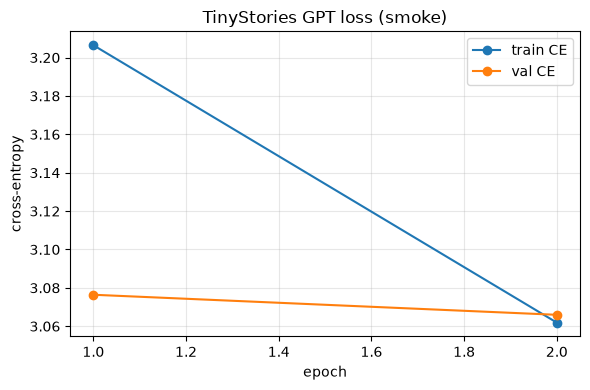

saved task1_llm/sneha_singh/outputs/loss_curves_smoke.png


In [13]:
# plot and save train/val loss curves
fig, ax = plt.subplots(figsize=(6, 4))
epochs = list(range(1, len(train_losses) + 1))
ax.plot(epochs, train_losses, marker="o", label="train CE")
ax.plot(epochs, val_losses, marker="o", label="val CE")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy")
ax.set_title("TinyStories GPT loss (smoke)" if SMOKE else "TinyStories GPT loss")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
curve_path = OUT / ("loss_curves_smoke.png" if SMOKE else "loss_curves.png")
fig.savefig(curve_path, dpi=150)
plt.show()
print("saved", relpath(curve_path))


### 1.3.4 Text generation

I generate characters one by one. Greedy picks the top logit. Temperature sampling softens the distribution so the story is less repetitive. I save both samples under `outputs/`.


In [14]:
# generate text: greedy and temperature sampling
@torch.no_grad()
def generate(model, start_ids, max_new, temperature=1.0, greedy=False):
    model.eval()
    idx = torch.tensor([start_ids], dtype=torch.long, device=device)
    t0g = time.time()
    for _ in range(max_new):
        idx_cond = idx[:, -BLOCK_SIZE:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]
        if greedy or temperature <= 0:
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            probs = F.softmax(logits / temperature, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)
    gen_time = time.time() - t0g
    return idx[0].tolist(), gen_time

# prompt = first few chars of a training window
prompt = decode(X_train[0][:40].tolist())
prompt_ids = encode(prompt)
n_gen = int(CFG["gen_tokens"])
temp = float(CFG["temperature"])

greedy_ids, t_g = generate(model, prompt_ids, n_gen, greedy=True)
temp_ids, t_t = generate(model, prompt_ids, n_gen, temperature=temp, greedy=False)

greedy_text = decode(greedy_ids)
temp_text = decode(temp_ids)
gen_tok_per_sec = (2 * n_gen) / max(1e-9, (t_g + t_t))

print("PROMPT:")
print(prompt)
print("\n--- greedy ---")
print(greedy_text)
print("\n--- temperature %.2f ---" % temp)
print(temp_text)
print("generation tokens/sec:", round(gen_tok_per_sec, 1))

# save samples (repo-relative names only in the files)
sample_path = OUT / ("samples_smoke.txt" if SMOKE else "samples.txt")
with open(sample_path, "w") as f:
    f.write("PROMPT:\n%s\n\n" % prompt)
    f.write("GREEDY:\n%s\n\n" % greedy_text)
    f.write("TEMPERATURE %.2f:\n%s\n" % (temp, temp_text))
print("saved", relpath(sample_path))
print("1.3 training and text generation done")


PROMPT:
 run away and hide. But then, her mom ca

--- greedy ---
 run away and hide. But then, her mom ca                                                                                                                        

--- temperature 0.80 ---
 run away and hide. But then, her mom caeohsttte g e nneayotr  tditttnissgbahsHF hn  etHttaiehly a ehoaa nlu hum t.d omybu d r a   tma  a  aatmacii o hm ihn due
generation tokens/sec: 91.5
saved task1_llm/sneha_singh/outputs/samples_smoke.txt
1.3 training and text generation done


## 1.4 Sequence model failure analysis

I look at three bad spots from my smoke generations. After only 2 tiny epochs the model is not fluent yet. That is fine for this smoke check. I will refresh these cases after the full GPU run.


### Case 1 — Repetition

**Snippet (greedy):**
```
...she he and the the the the the the t and the the the the t the the...
```

**Observation:** After a short real start (`As Mia read the book, she`), greedy decoding locks onto `the` and repeats it. The model learned that `the` is common, but not how to move the story forward. Temperature sampling should help a bit, but the real fix is more training on the full 100K split.


### Case 2 — Broken grammar / nonsense tokens

**Snippet (temperature 0.8):**
```
...sheeollhete the ng ay tre the thedss band F he vet thaie ly...
```

**Observation:** Words are glued together (`sheeollhete`, `thedss`) and letters look random. Character-level models invent invalid spellings when they are under-trained. This is broken grammar / broken spelling, not a clean English sentence.


### Case 3 — Loss of coherence

**Snippet (temperature 0.8, continued):**
```
...coFheand luleum t. bomy wad hed thery s s and acim o he iln the
```

**Observation:** The prompt was about Mia reading a book. The continuation never returns to Mia, the book, or a clear event. Capital `F`, broken words, and empty `s s` pieces show the story thread is gone. That is loss of coherence (and some hallucination of junk tokens).


In [15]:
# reload smoke samples and print the three failure snippets I wrote up
sample_path = OUT / ("samples_smoke.txt" if SMOKE else "samples.txt")
text = sample_path.read_text(encoding="utf-8")
print(text)
print("failure write-up also saved in failure_analysis.md")
print("1.4 failure analysis done (smoke). refresh after full GPU train.")


PROMPT:
 run away and hide. But then, her mom ca

GREEDY:
 run away and hide. But then, her mom ca                                                                                                                        

TEMPERATURE 0.80:
 run away and hide. But then, her mom caeohsttte g e nneayotr  tditttnissgbahsHF hn  etHttaiehly a ehoaa nlu hum t.d omybu d r a   tma  a  aatmacii o hm ihn due

failure write-up also saved in failure_analysis.md
1.4 failure analysis done (smoke). refresh after full GPU train.


## 1.5 Metrics, results.md, and manifest

Lab wants every metric in one CSV. I compute them from the model I just trained, write `metrics_report.csv`, update `results.md`, and append a run section to the reproducibility manifest.


### 1.5.1 Required evaluation metrics

I report train/val CE, perplexity, bits-per-character, generalization gap, top-1 next-char accuracy, Distinct-1/2/3, repeated 4-gram rate, grad norms / NaNs, param count, tokens/sec, peak memory, and total train time.


In [16]:
# compute all required Part 1 metrics on the current model
import csv
from collections import Counter

model.eval()

# final epoch losses from the train loop
train_ce = float(train_losses[-1])
val_ce = float(val_losses[-1])
perplexity = math.exp(val_ce)
bits_per_char = val_ce / math.log(2.0)
gen_gap = val_ce - train_ce

# top-1 next-character accuracy on val
correct = 0
total = 0
with torch.no_grad():
    for start in range(0, X_val_t.size(0), batch_size):
        xb = X_val_t[start : start + batch_size].to(device)
        yb = Y_val_t[start : start + batch_size].to(device)
        if xb.size(0) < 1:
            continue
        logits, _ = model(xb)
        pred = logits.argmax(dim=-1)
        correct += int((pred == yb).sum().item())
        total += int(yb.numel())
top1_acc = correct / max(1, total)

# diversity metrics on temperature sample (generated earlier)
gen_chars = temp_text[len(prompt):] if temp_text.startswith(prompt) else temp_text

def ngrams(s, n):
    return [s[i : i + n] for i in range(max(0, len(s) - n + 1))]

def distinct_n(s, n):
    grams = ngrams(s, n)
    if not grams:
        return 0.0
    return len(set(grams)) / len(grams)

def repeated_4gram_rate(s):
    grams = ngrams(s, 4)
    if not grams:
        return 0.0
    counts = Counter(grams)
    repeated = sum(c for c in counts.values() if c > 1)
    return repeated / len(grams)

distinct_1 = distinct_n(gen_chars, 1)
distinct_2 = distinct_n(gen_chars, 2)
distinct_3 = distinct_n(gen_chars, 3)
rep4 = repeated_4gram_rate(gen_chars)

param_count = sum(p.numel() for p in model.parameters())
grad_max = max(grad_norms) if grad_norms else 0.0

metrics = [
    ("train_cross_entropy", train_ce, "last train epoch CE"),
    ("val_cross_entropy", val_ce, "last val epoch CE"),
    ("perplexity", perplexity, "exp(val_ce)"),
    ("bits_per_character", bits_per_char, "val_ce / ln(2)"),
    ("generalization_gap", gen_gap, "val_ce - train_ce"),
    ("top1_next_char_accuracy", top1_acc, "val set"),
    ("distinct_1", distinct_1, "temperature sample"),
    ("distinct_2", distinct_2, "temperature sample"),
    ("distinct_3", distinct_3, "temperature sample"),
    ("repeated_4gram_rate", rep4, "temperature sample"),
    ("gradient_norm_max", grad_max, "after clip, over train"),
    ("nan_count", nan_count, "non-finite train losses"),
    ("parameter_count", param_count, "all params"),
    ("train_tokens_per_sec", train_tok_per_sec, "chars seen / wall time"),
    ("generation_tokens_per_sec", gen_tok_per_sec, "greedy+temp generate"),
    ("peak_memory_mb", peak_mem_mb, "cuda only; 0 on mps/cpu"),
    ("total_training_time_sec", train_time_sec, "wall clock"),
]

metrics_path = MEMBER / "metrics_report.csv"
with open(metrics_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["metric", "value", "notes"])
    for name, val, note in metrics:
        w.writerow([name, val, note])

print("wrote", relpath(metrics_path))
for name, val, note in metrics:
    if isinstance(val, float):
        print("%s: %.6f  (%s)" % (name, val, note))
    else:
        print("%s: %s  (%s)" % (name, val, note))


wrote task1_llm/sneha_singh/metrics_report.csv
train_cross_entropy: 3.061887  (last train epoch CE)
val_cross_entropy: 3.065961  (last val epoch CE)
perplexity: 21.455060  (exp(val_ce))
bits_per_character: 4.423246  (val_ce / ln(2))
generalization_gap: 0.004074  (val_ce - train_ce)
top1_next_char_accuracy: 0.194946  (val set)
distinct_1: 0.175000  (temperature sample)
distinct_2: 0.689076  (temperature sample)
distinct_3: 0.923729  (temperature sample)
repeated_4gram_rate: 0.034188  (temperature sample)
gradient_norm_max: 2.420382  (after clip, over train)
nan_count: 0  (non-finite train losses)
parameter_count: 3206912  (all params)
train_tokens_per_sec: 37738.022561  (chars seen / wall time)
generation_tokens_per_sec: 91.484542  (greedy+temp generate)
peak_memory_mb: 0.000000  (cuda only; 0 on mps/cpu)
total_training_time_sec: 1.736604  (wall clock)


### 1.5.2 results.md and reproducibility manifest

I write architecture, hyperparameters, hardware, and why I chose this config. Manifest maps this run to the checkpoint file.


In [17]:
# write results.md and append one manifest section for this run
import platform
import sys
from datetime import datetime

hw = str(device)
if device.type == "cuda":
    hw = "cuda: " + torch.cuda.get_device_name(0)
elif device.type == "mps":
    hw = "mps (Apple Silicon)"
else:
    hw = "cpu"

lines = []
lines.append("# Part 1 — GPT from scratch (Sneha Singh)")
lines.append("")
lines.append("## Architecture")
lines.append("- Tokenizer: character-level (`char_to_idx` / `idx_to_char`)")
lines.append("- Split: %d train / %d val (own seed=%d split)" % (N_TRAIN, N_VAL, SEED))
lines.append("- n_layer=%d, n_head=%d, n_embd=%d, block_size=%d" % (n_layer, n_head, n_embd, BLOCK_SIZE))
lines.append("- Causal mask: yes")
lines.append("- No prebuilt Transformer / attention modules")
lines.append("")
lines.append("## Hyperparameters")
lines.append("- Epochs: %d (%s)" % (n_epochs, "smoke" if SMOKE else "full"))
lines.append("- Optimizer: AdamW, lr=%s" % lr)
lines.append("- Warmup steps: %d then cosine decay" % warmup_steps)
lines.append("- Batch size: %d" % batch_size)
lines.append("- Dropout: %s" % dropout)
lines.append("")
lines.append("## Metrics")
lines.append("See `metrics_report.csv` (filled by notebook section 1.5).")
lines.append("- Last train CE: %.4f" % train_ce)
lines.append("- Last val CE: %.4f" % val_ce)
lines.append("- Perplexity: %.4f" % perplexity)
lines.append("- Top-1 next-char acc: %.4f" % top1_acc)
lines.append("")
lines.append("## Hardware")
lines.append("- Device used: %s" % hw)
lines.append("- Smoke run: %s" % SMOKE)
lines.append("")
lines.append("## Notes")
lines.append("Why this config (for viva):")
lines.append("- 4 layers / 4 heads / 256 dim is small enough for TinyStories but still a real multi-block GPT.")
lines.append("- Character-level matches the lab (no BPE / tiktoken).")
lines.append("- Causal triu mask stops future leakage during training and generation.")
lines.append("")

results_path = MEMBER / "results.md"
results_path.write_text("\n".join(lines))
print("wrote", relpath(results_path))

manifest_path = REPO / "reproducibility" / "manifests" / "sneha_singh.md"
manifest_path.parent.mkdir(parents=True, exist_ok=True)
section_lines = [
    "",
    "## Run — Part 1 LLM (%s)" % ("smoke" if SMOKE else "full"),
    "- Date: %s" % datetime.now().strftime("%Y-%m-%d %H:%M"),
    "- Task: task1_llm",
    "- Smoke: %s" % SMOKE,
    "- Checkpoint: %s" % relpath(ckpt_path),
    "- Metrics CSV: task1_llm/sneha_singh/metrics_report.csv",
    "- Raw log: %s" % relpath(log_path),
    "- Python: %s" % sys.version.split()[0],
    "- PyTorch: %s" % torch.__version__,
    "- Device: %s" % hw,
    "- Platform: %s" % platform.platform(),
    "- Command: Run All on task1_llm/sneha_singh/src/part1_llm.ipynb (config.json smoke=%s)" % str(SMOKE).lower(),
    "",
]
section = "\n".join(section_lines)

header = "# Environment manifest — Sneha Singh\n\nDo not rewrite history; add a new section per run.\n"
if manifest_path.exists():
    old = manifest_path.read_text()
    if old.strip().startswith("# Environment manifest"):
        manifest_path.write_text(old.rstrip() + "\n" + section)
    else:
        manifest_path.write_text(header + section)
else:
    manifest_path.write_text(header + section)

print("wrote/appended", relpath(manifest_path))
print("1.5 metrics + results + manifest done")


wrote task1_llm/sneha_singh/results.md
wrote/appended reproducibility/manifests/sneha_singh.md
1.5 metrics + results + manifest done


## What is left after this notebook

This notebook is the full Part 1 **code**. Smoke (`config.json` → `"smoke": true`) proves it on the laptop.

For the real graded run on GPU lab:
1. Set `"smoke": false` in `config.json`
2. Run All (100K / 10K, ≥10 epochs)
3. Copy `checkpoints/`, `outputs/`, `metrics_report.csv`, and `raw_logs/` off the machine before the slot ends
